In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import matplotlib as mpl
from padé import combined_full_model
import matplotlib.cm as cm

plt.rcParams.update(plt.rcParamsDefault)

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "xtick.top": True,
    "ytick.right": True,
})

In [19]:
def test_model_grid(test_folders, test_params, default_z_list,
                    base_path="/home/storgaard/OneDrive/Speciale/HALOFIT/C_256+2048",
                    num_bins=25, res_lims=[-5, 5]):
    """
    Dynamically loads N-body data for 6 tests, plotting all z-slices for a given test 
    inside a single subplot. Arranged in a 3x2 grid.
    
    test_params: A dictionary defining specific parameters for each test folder.
                 Example:
                 {
                     "test_1": {"dNeff": 0.0, "fidm": 0.0},
                     "test_5": {"dNeff": 0.1, "fidm": 0.05, "custom_z": [0, 0.5, 1.0]} 
                 }
    """
    
    if len(test_folders) > 6:
        print("Warning: More than 6 folders provided. Only plotting the first 6.")
        test_folders = test_folders[:6]
        
    rows, cols = 3, 2
    fig = plt.figure(figsize=(14, 16))
    # Outer gridspec for the 6 tests
    gs_outer = gridspec.GridSpec(rows, cols, wspace=0.15, hspace=0.10)

    for i, folder in enumerate(test_folders):
        row = i // cols
        col = i % cols
        
        # Extract test-specific parameters (default to 0 if not found)
        params = test_params.get(folder, {})
        dNeff_shift = params.get("dNeff", 0)
        fidm_shift = params.get("fidm", 0)
        
        # Check if this test requires a custom z-list (like test 5)
        if "test_5" in folder or "custom_z" in params:
            z_list = params.get("custom_z", [0.0, 0.5, 1.0, 2.0]) # Replace with your actual test 5 z-slices
        else:
            z_list = default_z_list

        # Setup inner gridspec for Main vs Residual
        gs_inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_outer[i], 
                                                    height_ratios=[3, 1], hspace=0.05)
        
        ax_main = fig.add_subplot(gs_inner[0])
        ax_res  = fig.add_subplot(gs_inner[1], sharex=ax_main)
        
        # Generate distinct colors for the different redshifts in this subplot
        colors = cm.turbo(np.linspace(0, 0.9, len(z_list)))

        # Loop over the redshift slices for this specific test
        for j, z in enumerate(z_list):
            file_name = f"Ck_z{z:.2f}.txt"
            file_path = os.path.join(base_path, folder, file_name)
            color = colors[j]
            
            try:
                # 1. Load Raw N-body data
                data = np.loadtxt(file_path, skiprows=1)
                raw_k = data[:, 0]
                raw_C = data[:, 1]
                
                # 2. Log-k Binning
                k_bins = np.logspace(np.log10(raw_k.min()), np.log10(raw_k.max()), num_bins + 1)
                data_k, data_C = [], []
                
                for b in range(num_bins):
                    mask = (raw_k >= k_bins[b]) & (raw_k < k_bins[b+1])
                    if np.any(mask):
                        data_k.append(np.exp(np.mean(np.log(raw_k[mask]))))
                        data_C.append(np.mean(raw_C[mask]))
                
                data_k = np.array(data_k)
                data_C = np.array(data_C)

                # 3. Get Emulator Prediction
                model_res = combined_full_model(data_k, z, dNeff_shift, fidm_shift)
                model_k = model_res['k']
                model_C = model_res['C']

                # 4. Calculate Residuals (%)
                residuals_pct = (data_C / model_C - 1) * 100

                # --- Plot Main ---
                # Using scatter for data and solid line for the model
                ax_main.scatter(data_k, data_C, color=color, alpha=0.5, s=20, marker='o')
                ax_main.plot(model_k, model_C, color=color, lw=1.5, label=f'$z = {z}$', zorder=10)

                # Insert text saying which test is shown in this subplot
                names = {
                    "test_1": "Test 1: dNeff=+1.75, fidm=-1.75",
                    "test_3": "Test 2: dNeff=-2.0, fidm=+0.75",
                    "test_4": "Test 3: dNeff=+2.5, fidm=-2.5",
                    "test_5": "Test 4: Baseline at high-z",
                    "test_6": "Test 5: dNeff=+3.5, fidm=+3.5",
                    "test_7": "Test 6: SIDR model, no fidm"
                }
                ax_main.text(0.75, 0.90, f"{names.get(folder, folder)}", transform=ax_main.transAxes, 
                             verticalalignment='center', horizontalalignment='center', 
                             fontsize=10, color='k', fontname = 'Serif')

                # --- Plot Residuals ---
                ax_res.plot(data_k, residuals_pct, 'o', markersize=3, color=color, alpha=0.7)

            except FileNotFoundError:
                print(f"Warning: File {file_path} not found. Skipping redshift z={z} for {folder}.")
                
                

        # Formatting Main Panel
        ax_main.set_xscale('log')
        # Only set y-labels for the left column
        if col == 0:
            ax_main.set_ylabel(r'$C(k)$')
        if row == 0 and col == 0:
            ax_main.legend(frameon=False, loc='lower left', fontsize='small', ncol=2)
        # Also make legend for high z slice in test 5 more visible
        if "test_5" in folder:
            ax_main.legend(frameon=False, loc='lower left', fontsize='small', ncol=2)
        plt.setp(ax_main.get_xticklabels(), visible=False)

        # Formatting Residual Panel
        ax_res.axhline(0, color='black', lw=1, ls='-')
        ax_res.hlines([2, -2], color='grey', lw=1, ls='--', xmin=1e-3, xmax=1e1) # Fixed xmin/xmax safely
        
        if col == 0:
            ax_res.set_ylabel(r'Res [%]')
        ax_res.set_ylim(*res_lims)
        # Change the res lims for test 5 and 6
        if "test_5" in folder:
            ax_res.set_ylim(-8, 8)
        elif "test_6" in folder:
            ax_res.set_ylim(-10, 25)
        elif "test_4" in folder or "test_1" in folder:
            ax_res.set_ylim(-7, 7)
        
        # Only add x-labels to the bottom row of the outer grid
        if row == rows - 1:
            ax_res.set_xlabel(r'$k$ [$1/\mathrm{Mpc}$]')

    fig.savefig("6_tests_comparison_pade.pdf", dpi=300, bbox_inches='tight')
    plt.show()



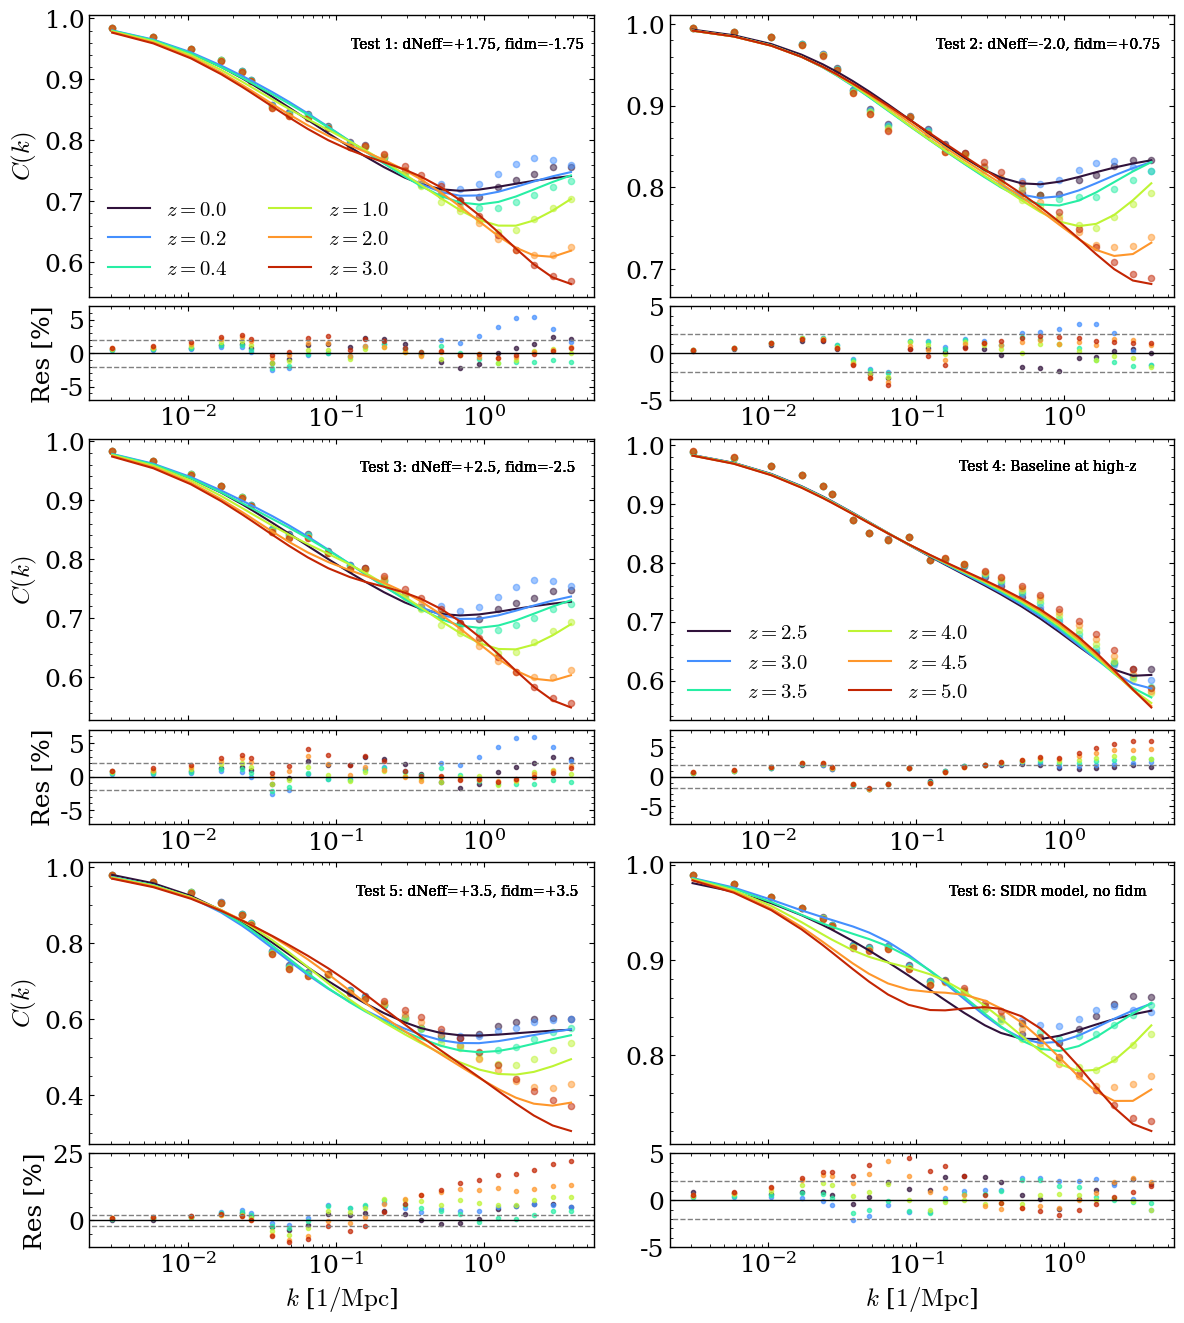

In [20]:
# ==========================================
# Example usage:
# ==========================================
folders = ["test_1", "test_3", "test_4", "test_5", "test_6", "test_7"]
params = {
    "test_1": {"dNeff": 1.75, "fidm": -1.75},
    "test_3": {"dNeff": -2.0, "fidm": 0.75},
    "test_4": {"dNeff": 2.5, "fidm": -2.5},
    "test_5": {"dNeff": 0.2, "fidm": 0.1, "custom_z": [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]},
    "test_6": {"dNeff": 3.5, "fidm": 3.5},
    "test_7": {"dNeff": 0, "fidm": -3.75}
}
default_zs = [0.0, 0.2, 0.4, 1.0, 2.0, 3.0]

test_model_grid(folders, params, default_zs)